# Extension of the shallow masked diffusion

## Professor's problem notation

We fix a latent dimension $D$. For each experiment, we choose

$$
\gamma = \frac{N}{D}, 
\qquad 
\alpha = \frac{M}{D},
$$

where:

- $D$ is the latent dimension;
- $N$ is the visible binary sequence length;
- $M$ is the number of training samples;
- $\gamma$ controls the visible dimension relative to the latent dimension;
- $\alpha$ controls the sample load relative to the latent dimension.

The data are generated from a random-feature / hidden-manifold model:

$$
F_{ij} \sim \mathcal N\left(0,\frac{1}{D}\right),
\qquad
F \in \mathbb R^{N \times D},
$$

$$
z^\mu \sim \mathcal N(0,I_D),
\qquad
x^\mu = \operatorname{sign}(Fz^\mu)\in\{-1,+1\}^N,
\qquad
\mu=1,\dots,M.
$$

The shallow masked diffusion model predicts masked coordinates from the visible coordinates.  
For a masked coordinate $i$,

$$
p_\theta(x_i^\mu=1\mid x_t^\mu)
=
\sigma\left(
\sum_{j:x_j^t\neq [m]} W_{ij}x_j^\mu
\right).
$$

Equivalently, if $m_j^t=1$ means that coordinate $j$ is masked and $m_j^t=0$ means that it is visible,

$$
p_\theta(x_i^\mu=1\mid x_t^\mu)
=
\sigma\left(
\sum_{j=1}^N (1-m_j^t)W_{ij}x_j^\mu
\right).
$$

We vary $\alpha=M/D$ and $\gamma=N/D$ at fixed $D$.


## Translation to the codebase

The professor's notation is not identical to the repository notation.

In the codebase:

$$
L = N,
$$

because the masked diffusion model acts on binary vectors of length $N$.  
The repository's training argument `alpha` means

$$
\alpha_{\mathrm{code}} = \frac{M}{L} = \frac{M}{N}.
$$

Therefore, when the professor's parameters are

$$
\alpha = \frac{M}{D},
\qquad
\gamma = \frac{N}{D},
$$

the codebase value must be

$$
\alpha_{\mathrm{code}}
=
\frac{M}{N}
=
\frac{\alpha D}{\gamma D}
=
\frac{\alpha}{\gamma}.
$$

So in the notebook we use:

$$
N = \operatorname{round}(\gamma D),
\qquad
M = \operatorname{round}(\alpha D),
\qquad
\alpha_{\mathrm{code}} = \frac{M}{N}.
$$

### Notation Mapping Table

| Professor notation | Meaning                    | Code variable                 |
| ------------------ | -------------------------- | ----------------------------- |
| $D$                | latent dimension           | `D` or `n_hidden`             |
| $N$                | visible binary dimension   | `N`, also `L` in model        |
| $M$                | number of training samples | `M_train`                     |
| $\gamma=N/D$       | visible-to-latent ratio    | `gamma`                       |
| $\alpha=M/D$       | sample load                | `sample_load` or `alpha_prof` |
| $M/N$              | repository training ratio  | `alpha_code`                  |


## 3. Imports

We import standard numerical libraries, PyTorch, PyTorch Lightning, and the classes `RandomFeaturesDataset` and `MaskedDiffusion` from our codebase.

In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
from torch.utils.data import Subset, DataLoader

# Robust path logic: add the project root directory containing datasets.py and diffusion.py
notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from datasets import RandomFeaturesDataset
from diffusion import MaskedDiffusion


## 4. Fixed Parameters

We specify the fixed parameters for the training sweep. We set the latent dimension $D=20$. We define list parameters for the visible-to-latent ratio $\gamma$ (`gamma_values`) and sample load $\alpha$ (`sample_load_values`). The masking probability $t_{\mathrm{mask}}$ is determined by a fixed context size $K = \text{round}(\kappa \cdot D)$ with $\kappa = 0.5$.


In [2]:
# Fixed Parameter Setup
D = 20  # fixed latent dimension
gamma_values = [1.0, 2.0, 4.0]  # visible ratio N/D (gamma)
sample_load_values = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]  # sample load M/D (professor's alpha)

# Masking setup (fixed context ratio relative to latent dimension kappa = K/D)
kappa = 0.5
M_test = 1000  # fixed number of test samples
num_steps = 2000  # fixed number of optimizer updates per training run
n_eval_mc = 50  # number of Monte Carlo samples for loss evaluation


## 5. Fixed random-feature matrix $F$

For each fixed pair $(D, \gamma)$, we instantiate one `RandomFeaturesDataset` containing a fixed random matrix $F \in \mathbb R^{N \times D}$.

Mathematically, the data generation matches:

$$
x = \operatorname{sign}(z F^\top),
\qquad
F \in \mathbb R^{N \times D},
\qquad
F_{ij} \sim \mathcal N\left(0, \frac{1}{D}\right),
\qquad
z \sim \mathcal N(0, I_D).
$$

In the codebase, the dataset class `RandomFeaturesDataset` constructs $F$ with shape `(n_visible, n_hidden)` and divides by $\sqrt{n_{\mathrm{hidden}}}$ (which is $D^{0.5}$), samples $z \in \mathbb R^{M \times n_{\mathrm{hidden}}}$, and returns the activation function applied to $z F^\top$. Under the mapping `n_visible = N` and `n_hidden = D`, the dataset instantiation is:

```python
dataset = RandomFeaturesDataset(
    n_visible=N,
    n_hidden=D,
    num_samples=M_train + M_test,
    act=torch.sign,
)
```

This matches the professor's random hidden-feature model exactly.

For each sample size $M_{\mathrm{train}} = \operatorname{round}(\alpha D)$, we draw the first $M_{\mathrm{train}}$ samples from this dataset. The test set is drawn from the remaining portion of the same dataset pool, which ensures that all points on the curves correspond to the same underlying population distribution $p_F$.


## 6. Fixed-Step Training Helper

We define a helper function to train the `MaskedDiffusion` model for exactly `num_steps` optimizer updates. This avoids the artifact where larger datasets receive more optimization steps (which occurs when training for a fixed number of epochs). In each step:
1. We sample a mini-batch from the training dataset.
2. We compute the masked logistic loss using the codebase function `model._compute_loss(batch, t=t_mask)`.
3. We add the L2 regularization loss configured via `model.l2coeff * model.sqnorm()`.
4. We backpropagate the gradients and update the weights.

In [3]:
def train_model(train_dataset, config, num_steps, t_mask):
    model = MaskedDiffusion(config)
    # Ensure optimizer is configured
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=0.0)
    
    # Setup data loader
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
    
    model.train()
    step = 0
    iterator = iter(train_loader)
    
    while step < num_steps:
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(train_loader)
            batch = next(iterator)
            
        optimizer.zero_grad()
        # Compute loss at the fixed masking level t_mask
        loss, acc = model._compute_loss(batch, t=t_mask)
        # Add L2 penalty consistent with codebase training step
        total_loss = loss + model.l2coeff * model.sqnorm()
        
        total_loss.backward()
        optimizer.step()
        step += 1
        
    return model


## 7. Evaluation Helper

We define a helper function to evaluate the train or test loss and accuracy on a given dataset. To get a precise estimate of the loss under the fixed masking context, we compute the expectation over multiple Monte Carlo samples (given by `n_eval_mc`) using the existing `model._compute_loss` method at the fixed masking level $t_{\mathrm{mask}}$.

In [4]:
@torch.no_grad()
def evaluate_model(model, dataset, mc_samples, t_mask):
    model.eval()
    # Load entire dataset as a single batch for evaluation
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    batch = next(iter(loader))
    loss, acc = model._compute_loss(batch, t=t_mask, mc_samples=mc_samples)
    return loss.item(), acc


## 8. Run Sweep over $\gamma$ and $\alpha$

We perform a nested loop over the visible-to-latent ratios $\gamma \in \text{gamma\_values}$ and sample loads $\alpha \in \text{sample\_load\_values}$ at a fixed latent dimension $D = 20$. For each pair $(D, \gamma)$, we generate a single fixed random-feature dataset pool. Then, for each sample load $\alpha$, we construct a training subset containing the first $M_{\mathrm{train}} = \text{round}(\alpha \cdot D)$ samples, configure the model, train it for exactly `num_steps`, and evaluate the train and test losses.


In [5]:
# Run the training sweep over gamma and sample_load values
results_list = []

for gamma in gamma_values:
    # Compute visible dimension and max sample size for this (D, gamma)
    N = int(round(gamma * D))
    M_max = int(round(max(sample_load_values) * D))
    
    # Calculate masking level corresponding to K visible context coordinates
    # using Option B: fixed context ratio kappa = K/D
    K = int(round(kappa * D))
    t_mask_val = 1.0 - (K / N)
    
    # Create the fixed random-feature matrix F once for this (D, gamma)
    full_dataset = RandomFeaturesDataset(
        n_visible=N,
        n_hidden=D,
        num_samples=M_max + M_test,
        act=torch.sign,
    )
    
    test_dataset = Subset(full_dataset, list(range(M_max, M_max + M_test)))
    
    for sample_load in sample_load_values:
        M_train = int(round(sample_load * D))
        alpha_code = M_train / N  # codebase ratio M_train/N
        
        # Construct subset containing the first M_train samples from the training pool
        train_dataset = Subset(full_dataset, list(range(M_train)))
        
        # SimpleNamespace config required by MaskedDiffusion
        config = SimpleNamespace(
            L=N,
            alpha=alpha_code,
            model="linear",
            l2reg=0.0,
            lr=0.005,
            epochs=1,  # required field in config but not used in our loop
            batch_size=min(M_train, 512),
            freeze_mask_weights=True,
            bias=False,
            pbar=False,
        )
        
        print(f"Training for D = {D}, gamma = {gamma:.1f}, sample_load = {sample_load:5.1f} (M_train = {M_train:4d}) ...")
        model = train_model(train_dataset, config, num_steps, t_mask=t_mask_val)
        
        # Evaluate model
        train_loss, train_acc = evaluate_model(model, train_dataset, n_eval_mc, t_mask=t_mask_val)
        test_loss, test_acc = evaluate_model(model, test_dataset, n_eval_mc, t_mask=t_mask_val)
        
        print(f"  Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f}")
        
        results_list.append({
            "D": D,
            "N": N,
            "M_train": M_train,
            "sample_load": sample_load,
            "gamma": gamma,
            "alpha_code": alpha_code,
            "K": K,
            "t_mask": t_mask_val,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "train_acc": train_acc,
            "test_acc": test_acc
        })


Training for D = 20, gamma = 1.0, sample_load =   0.5 (M_train =   10) ...


  Train loss: 0.2542 | Test loss: 1.1057
Training for D = 20, gamma = 1.0, sample_load =   1.0 (M_train =   20) ...


  Train loss: 0.4203 | Test loss: 0.8939
Training for D = 20, gamma = 1.0, sample_load =   2.0 (M_train =   40) ...


  Train loss: 0.5165 | Test loss: 0.7413
Training for D = 20, gamma = 1.0, sample_load =   5.0 (M_train =  100) ...


  Train loss: 0.5818 | Test loss: 0.6500
Training for D = 20, gamma = 1.0, sample_load =  10.0 (M_train =  200) ...


...

  Train loss: 0.5765 | Test loss: 0.6416
Training for D = 20, gamma = 4.0, sample_load =  10.0 (M_train =  200) ...


  Train loss: 0.5868 | Test loss: 0.6238
Training for D = 20, gamma = 4.0, sample_load =  20.0 (M_train =  400) ...


  Train loss: 0.5966 | Test loss: 0.6139
Training for D = 20, gamma = 4.0, sample_load =  50.0 (M_train = 1000) ...


  Train loss: 0.6015 | Test loss: 0.6087
Training for D = 20, gamma = 4.0, sample_load = 100.0 (M_train = 2000) ...


  Train loss: 0.6037 | Test loss: 0.6070


## 9. Results Dataframe

We display the sweep results as a pandas DataFrame. This shows the precise numbers for each value of sample load $\alpha = M/D$ and visible ratio $\gamma = N/D$.


In [6]:
# Convert results list to DataFrame
df = pd.DataFrame(results_list)
df

,D,N,M_train,sample_load,gamma,alpha_code,K,t_mask,train_loss,test_loss,train_acc,test_acc
0,20,20,10,0.5,1.0,0.500,10,0.500,0.254217,1.105662,0.886450,0.579478
1,20,20,20,1.0,1.0,1.000,10,0.500,0.420334,0.893925,0.800257,0.580262
2,20,20,40,2.0,1.0,2.000,10,0.500,0.516481,0.741302,0.737193,0.602300
3,20,20,100,5.0,1.0,5.000,10,0.500,0.581839,0.649996,0.687045,0.633764
4,20,20,200,10.0,1.0,10.000,10,0.500,0.587142,0.630452,0.682296,0.648143
5,20,20,400,20.0,1.0,20.000,10,0.500,0.603980,0.620471,0.667793,0.654293
6,20,20,1000,50.0,1.0,50.000,10,0.500,0.606621,0.614753,0.666103,0.658972
7,20,20,2000,100.0,1.0,100.000,10,0.500,0.608563,0.614400,0.663840,0.659043
8,20,40,10,0.5,2.0,0.250,10,0.750,0.292672,1.040286,0.869711,0.572124
9,20,40,20,1.0,2.0,0.500,10,0.750,0.432946,0.831692,0.791239,0.592006


## 10. Plots

We produce a single unified plot showing the Train and Test Masked-Diffusion Loss as a function of the sample load $\alpha = M/D$ (on a log scale) for different visible-to-latent ratios $\gamma = N/D \in \{1.0, 2.0, 4.0\}$ at a fixed latent dimension $D=20$.

The curves are grouped by $\gamma = N/D$ using different colors, with solid lines representing the Train Loss and dashed lines representing the Test Loss.


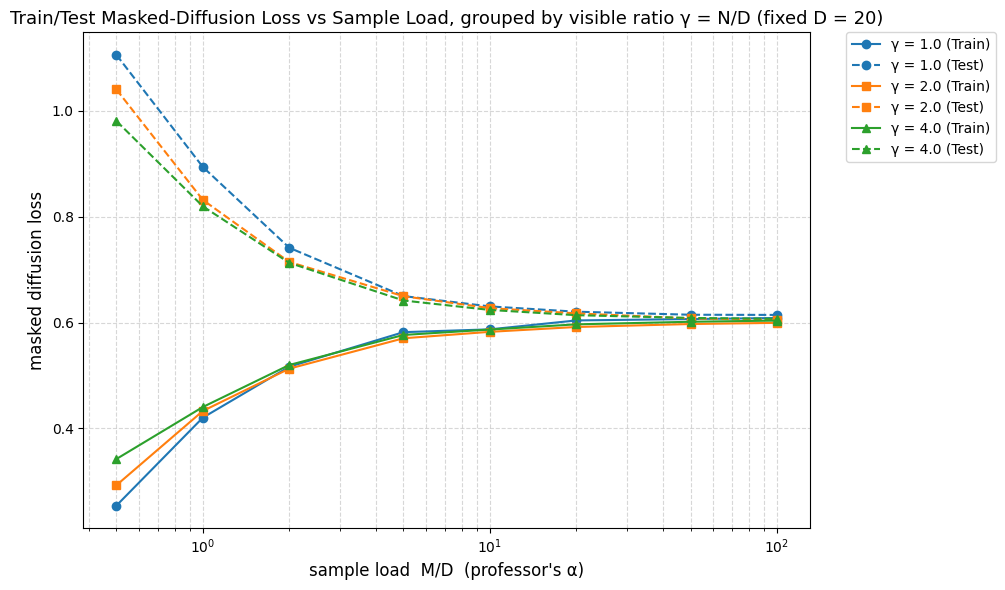

In [7]:
# Generate the unified convergence plot grouped by gamma

plt.figure(figsize=(10, 6))

# Define colors and markers for each gamma value
colors = {1.0: "#1f77b4", 2.0: "#ff7f0e", 4.0: "#2ca02c"}
markers = {1.0: "o", 2.0: "s", 4.0: "^"}

for gamma in gamma_values:
    sub_df = df[df["gamma"] == gamma]
    if sub_df.empty:
        continue
    color = colors.get(gamma, "#7f7f7f")
    marker = markers.get(gamma, "d")
    
    # Plot Train Loss (solid line)
    plt.plot(
        sub_df["sample_load"], 
        sub_df["train_loss"], 
        linestyle="-", 
        marker=marker, 
        color=color, 
        label=f"γ = {gamma:.1f} (Train)"
    )
    
    # Plot Test Loss (dashed line)
    plt.plot(
        sub_df["sample_load"], 
        sub_df["test_loss"], 
        linestyle="--", 
        marker=marker, 
        color=color, 
        label=f"γ = {gamma:.1f} (Test)"
    )

plt.xscale("log")
plt.xlabel("sample load  M/D  (professor's α)", fontsize=12)
plt.ylabel("masked diffusion loss", fontsize=12)
plt.title("Train/Test Masked-Diffusion Loss vs Sample Load, grouped by visible ratio γ = N/D (fixed D = 20)", fontsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("loss_convergence_grouped.png", bbox_inches="tight")
plt.show()


## 11. Interpretation and Connection to Statistical Physics

We fix the latent dimension $D$. For each pair $(\alpha, \gamma)$, we set the number of training samples $M = \operatorname{round}(\alpha D)$ and visible dimension $N = \operatorname{round}(\gamma D)$. We generate $M$ training patterns and a much larger test set from the same fixed random feature model. We train the linear masked diffusion model and compare the empirical train loss with the population/test loss.

The expected numerical signature is that the train loss is optimistic at small $M/D$ (below the thermodynamic limit), while the test loss is pessimistic; as $M/D$ grows, both approach the same limiting risk.

### Statistical Physics Context

This behavior is aligned with the statistical-physics convention of studying proportional limits where ratios such as $P/N$, $M/L$, or here ($M/D, N/D$), are held $O(1)$. The perceptron notes introduce this logic through the constraint density $\alpha = P/N$, i.e., dataset size divided by dimension.

### Connection to D3PMs and Masked Diffusion

This is a masked/absorbing discrete diffusion setup. Discrete Denoising Diffusion Probabilistic Models (D3PMs) explicitly connect absorbing-state corruption with autoregressive and mask-based generative models. Recent masked diffusion work formulates the training objective as weighted cross-entropy over masked tokens. For more details, see [Structured Denoising Diffusion Models in Discrete State-Spaces (arXiv)](https://arxiv.org/abs/2107.03006?utm_source=chatgpt.com).
